# Contract Intelligence Multi-Agent System
## Assignment Notebook - 8-Week Capstone Project

**Course**: Agentic AI Bootcamp - Staff-Level System Design

---

## Welcome to Your Capstone Assignment!

This notebook is your guided journey to building a **production-grade multi-agent contract intelligence system**. Unlike the master solution, YOU will implement the core functionality.

### How This Assignment Works

1. **Scaffolding Provided**: Class structures, function signatures, and imports are given
2. **TODO Markers**: Look for `# TODO:` comments - these are YOUR tasks
3. **Hints**: Each section has hints to guide you (but not give away the answer)
4. **Validation Cells**: Run these to check if your implementation is correct
5. **Expected Output**: Sample outputs show what success looks like

### Difficulty Progression

| Week | Difficulty | Focus |
|------|-----------|-------|
| 1 | Easy | Environment setup (mostly provided) |
| 2 | Easy-Medium | Document processing methods |
| 3 | Medium | Vector store search functions |
| 4 | Medium-Hard | Implement agents from scratch |
| 5 | Hard | Multi-agent orchestration |
| 6 | Medium | Build knowledge graph |
| 7 | Medium | Add observability metrics |
| 8 | Hard | Integrate everything |

### Grading Rubric

- **Week 1-2**: 15% (Foundation)
- **Week 3-4**: 30% (Core Components)  
- **Week 5-6**: 30% (Advanced Features)
- **Week 7-8**: 25% (Production Polish)

Let's begin!

---

# WEEK 1: Environment & Foundations

**Difficulty: Easy** - Most code is provided. Focus on understanding.

---

## Learning Objectives

By the end of Week 1, you will:
- [ ] Set up all required packages
- [ ] Configure API keys securely
- [ ] Initialize Langfuse for observability
- [ ] Create traced wrapper functions
- [ ] Explore the contract data structure

---

## 1.1 Package Installation

This section is **provided** - just run the cell to install packages.

In [1]:
# ============================================================================
# WEEK 1.1: PACKAGE INSTALLATION (PROVIDED)
# ============================================================================
# Pinned versions for reproducibility. Every package is verified after install.

import subprocess, sys

_packages = ["openai==1.59.6", "langfuse==2.57.1", "langchain==0.3.14", "langchain-openai==0.2.14", "langchain-community==0.3.14", "langchain-core==0.3.29", "chromadb", "networkx", "pyvis", "python-docx", "openpyxl", "plotly", "seaborn", "pydantic>=2.0", "tenacity", "rich", "gradio", "python-dotenv", "numpy", "pandas", "matplotlib"]

print("Installing packages (this may take 1-2 minutes)...")
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q"] + _packages,
    capture_output=True, text=True
)

if result.returncode != 0:
    for line in result.stderr.split("\n"):
        if line.strip() and "dependency resolver" not in line.lower() and "notice" not in line.lower():
            print(line)

# ---------- Verify EVERY import ----------
_verify = [
    ("openai", "openai"),
    ("langfuse", "langfuse"),
    ("langchain", "langchain"),
    ("langchain_openai", "langchain_openai"),
    ("chromadb", "chromadb"),
    ("networkx", "networkx"),
    ("pyvis", "pyvis.network"),
    ("docx", "docx"),
    ("openpyxl", "openpyxl"),
    ("plotly", "plotly"),
    ("seaborn", "seaborn"),
    ("pydantic", "pydantic"),
    ("tenacity", "tenacity"),
    ("rich", "rich"),
    ("gradio", "gradio"),
    ("dotenv", "dotenv"),
    ("fastapi", "fastapi"),
    ("uvicorn", "uvicorn"),
]

_failed = []
for name, imp in _verify:
    try:
        __import__(imp)
    except ImportError:
        _failed.append(name)

if _failed:
    msg = f"FATAL: These packages failed to import: {', '.join(_failed)}\n"
    msg += "Try: Runtime > Restart runtime, then re-run this cell."
    raise ImportError(msg)

print("=" * 60)
print(f"All {len(_verify)} packages installed and verified!")
print("=" * 60)

Installing packages (this may take 1-2 minutes)...


e:\Sheriff_faang\full_end_to_end_project_implementation\IK_PWC_Agentic_AI_Project\PWC_CAPSTONE_PROJECT\IK_PWC_COURSE_CAPSTONE_PROJECTS\.contract\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All 18 packages installed and verified!


## 1.2 Environment Configuration

This section is **provided** - handles environment detection and imports.

In [2]:
# ============================================================================
# WEEK 1.2: ENVIRONMENT DETECTION (PROVIDED)
# ============================================================================

import os
import sys
import json
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
from typing import List, Dict, Optional, Any, Tuple
from dataclasses import dataclass, field
from enum import Enum
import warnings
warnings.filterwarnings('ignore')

# Environment detection
IN_COLAB = 'google.colab' in sys.modules

print(f"Runtime Environment: {'Google Colab' if IN_COLAB else 'Local/Other'}")
print(f"Python Version: {sys.version.split()[0]}")

Runtime Environment: Local/Other
Python Version: 3.12.7


In [3]:
# ============================================================================
# API KEY CONFIGURATION (PROVIDED)
# ============================================================================

import subprocess

DATASET_REPO = "https://github.com/AI-Project-Lab/IK-pwc-agenticai-datasets.git"
DATASET_PROJECT = "contract_intelligence"

if IN_COLAB:
    print("Configuring for Google Colab environment...")

    # --- API Key Configuration ---
    try:
        from google.colab import userdata
        os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
        os.environ['LANGFUSE_SECRET_KEY'] = userdata.get('LANGFUSE_SECRET_KEY')
        os.environ['LANGFUSE_PUBLIC_KEY'] = userdata.get('LANGFUSE_PUBLIC_KEY')
        _host = userdata.get('LANGFUSE_HOST') or ''
        os.environ['LANGFUSE_HOST'] = _host if _host.startswith('http') else 'https://cloud.langfuse.com'
        print("API keys loaded from Colab Secrets")
    except Exception as e:
        print(f"Colab Secrets not available: {e}")
        import getpass
        os.environ['OPENAI_API_KEY'] = getpass.getpass('Enter OpenAI API Key: ')
        os.environ['LANGFUSE_SECRET_KEY'] = getpass.getpass('Enter Langfuse Secret Key: ')
        os.environ['LANGFUSE_PUBLIC_KEY'] = getpass.getpass('Enter Langfuse Public Key: ')
        os.environ['LANGFUSE_HOST'] = 'https://cloud.langfuse.com'

    # --- Dataset Ingestion from GitHub ---
    dataset_path = "/content/datasets"
    if not os.path.exists(f"{dataset_path}/{DATASET_PROJECT}"):
        print(f"\nCloning dataset from {DATASET_REPO}...")
        subprocess.run(["git", "clone", "--depth", "1", DATASET_REPO, dataset_path],
                       check=True, capture_output=True)
        print("Dataset cloned successfully!")
    else:
        print("\nDataset already available.")
    DATA_DIR_BASE = f"{dataset_path}/{DATASET_PROJECT}"
else:
    print("Configuring for local environment...")
    from dotenv import load_dotenv
    load_dotenv()

    # --- Dataset Ingestion from GitHub ---
    datasets_parent = Path('.').resolve().parent.parent / 'datasets'
    if not (datasets_parent / DATASET_PROJECT).exists():
        print(f"\nCloning dataset from {DATASET_REPO}...")
        subprocess.run(["git", "clone", "--depth", "1", DATASET_REPO, str(datasets_parent)],
                       check=True, capture_output=True)
        print("Dataset cloned successfully!")
    else:
        print("\nDataset already available locally.")
    DATA_DIR_BASE = str(datasets_parent / DATASET_PROJECT)

# Validate API keys
required_keys = ['OPENAI_API_KEY', 'LANGFUSE_SECRET_KEY', 'LANGFUSE_PUBLIC_KEY']
missing_keys = [key for key in required_keys if not os.environ.get(key)]
if missing_keys:
    raise EnvironmentError(f"Missing required API keys: {missing_keys}")

PROJECT_NAME = "contract-intelligence-system"
DATA_DIR = Path(DATA_DIR_BASE)
print(f"\nAll API keys validated successfully")
print(f"Data directory: {DATA_DIR}")
print(f"Directory exists: {DATA_DIR.exists()}")
if DATA_DIR.exists():
    file_count = sum(1 for _ in DATA_DIR.rglob('*') if _.is_file())
    print(f"Total files found: {file_count}")

Configuring for local environment...

Dataset already available locally.

All API keys validated successfully
Data directory: E:\Sheriff_faang\full_end_to_end_project_implementation\IK_PWC_Agentic_AI_Project\PWC_CAPSTONE_PROJECT\IK_PWC_COURSE_CAPSTONE_PROJECTS\datasets\contract_intelligence
Directory exists: True
Total files found: 36


## 1.3 Langfuse Initialization

**YOUR FIRST TODO!** Initialize the Langfuse client.

### Hints:
- Import `Langfuse` from `langfuse`
- Import `observe` and `langfuse_context` from `langfuse.decorators`
- Use environment variables for credentials
- Call `auth_check()` to verify connection

In [4]:
# ============================================================================
# WEEK 1.3: LANGFUSE INITIALIZATION
# ============================================================================

from langfuse import Langfuse
from langfuse.decorators import observe, langfuse_context
from openai import OpenAI

langfuse = Langfuse(
    secret_key=os.environ.get("LANGFUSE_SECRET_KEY"),
    public_key=os.environ.get("LANGFUSE_PUBLIC_KEY"),
    host=os.environ.get("LANGFUSE_HOST", "https://cloud.langfuse.com"),
)

try:
    langfuse.auth_check()
    print("Langfuse connection verified!")
except Exception as exc:
    print(f"Langfuse auth check failed: {exc}")

SESSION_ID = datetime.now().strftime("contract-intel-%Y%m%d-%H%M%S")
print(f"Session ID: {SESSION_ID}")


Langfuse connection verified!
Session ID: contract-intel-20260914-152803


### Expected Output for 1.3:
```
Langfuse connection verified!
Session ID: contract-intel-20250127-143052
```

## 1.4 Traced Wrapper Functions

**TODO:** Implement traced versions of OpenAI calls.

### Hints:
- Create a trace with `langfuse.trace()`
- Create a generation span with `trace.generation()`
- Use `openai_client.embeddings.create()` for embeddings
- End the generation with usage stats

In [5]:
# ============================================================================
# WEEK 1.4: TRACED EMBEDDING FUNCTION
# ============================================================================

openai_client = OpenAI()

def traced_embedding(text: str, trace_name: str = "embedding") -> List[float]:
    """Generate an embedding with Langfuse tracing."""
    trace = langfuse.trace(name=trace_name, session_id=SESSION_ID, metadata={"type": "embedding", "model": "text-embedding-3-small"})
    generation = trace.generation(name="openai-embedding", model="text-embedding-3-small", input={"text": text})
    response = openai_client.embeddings.create(model="text-embedding-3-small", input=text)
    embedding = response.data[0].embedding
    generation.end(output={"embedding_length": len(embedding)}, usage={"prompt_tokens": getattr(response.usage, "prompt_tokens", 0), "total_tokens": getattr(response.usage, "total_tokens", 0)})
    return embedding

print("traced_embedding() function defined")


traced_embedding() function defined


In [6]:
# ============================================================================
# WEEK 1.4: TRACED COMPLETION FUNCTION
# ============================================================================

def traced_completion(prompt: str, trace_name: str = "completion") -> str:
    """Generate a completion with Langfuse tracing."""
    trace = langfuse.trace(name=trace_name, session_id=SESSION_ID, metadata={"type": "completion", "model": "gpt-4o-mini"})
    generation = trace.generation(name="openai-completion", model="gpt-4o-mini", input={"prompt": prompt})
    response = openai_client.chat.completions.create(model="gpt-4o-mini", messages=[{"role": "user", "content": prompt}])
    response_text = response.choices[0].message.content
    generation.end(output={"content": response_text}, usage={"prompt_tokens": getattr(response.usage, "prompt_tokens", 0), "completion_tokens": getattr(response.usage, "completion_tokens", 0), "total_tokens": getattr(response.usage, "total_tokens", 0)})
    return response_text

print("traced_completion() function defined")


traced_completion() function defined


## 1.5 Contract Document Taxonomy

**PROVIDED** - Study this structure carefully, you'll need it later.

In [7]:
# ============================================================================
# WEEK 1.5: CONTRACT TAXONOMY (PROVIDED)
# ============================================================================

CONTRACT_CATEGORIES = {
    'master_agreements': {
        'path': 'Master level agreements',
        'description': 'Foundation contracts establishing overall relationship',
        'document_types': ['MSA', 'NDA', 'Rate Cards'],
        'risk_focus': ['legal', 'compliance'],
    },
    'transaction_contracts': {
        'path': 'Transaction level contract',
        'description': 'Project-specific agreements under master agreements',
        'document_types': ['SOW', 'Work Orders', 'Renewals', 'Amendments'],
        'risk_focus': ['operational', 'financial'],
    },
    'commercial_docs': {
        'path': 'Commercial docs',
        'description': 'Pricing and commercial terms documentation',
        'document_types': ['Pricing Tables', 'Rate Schedules'],
        'risk_focus': ['financial'],
    },
    'financial_billing': {
        'path': 'Financial and Billing docs',
        'description': 'Invoices, payment records, and billing schedules',
        'document_types': ['Invoices', 'Credit Notes', 'Payment Schedules'],
        'risk_focus': ['financial'],
    },
    'operational_docs': {
        'path': 'Operational service delivery docs',
        'description': 'Service delivery and operational documentation',
        'document_types': ['Service Reports', 'SLA Reports'],
        'risk_focus': ['operational'],
    },
    'compliance_docs': {
        'path': 'Compliance and policy documents',
        'description': 'Security, compliance, and policy documentation',
        'document_types': ['InfoSec Controls', 'Vendor Policies'],
        'risk_focus': ['compliance'],
    },
    'legal_support': {
        'path': 'Legal support documents',
        'description': 'Legal correspondence and supporting documentation',
        'document_types': ['Legal Memos', 'Correspondence'],
        'risk_focus': ['legal'],
    },
    'relationship_governance': {
        'path': 'Relationship and governance docs',
        'description': 'Governance frameworks and relationship management',
        'document_types': ['Governance Frameworks', 'Escalation Matrices'],
        'risk_focus': ['operational', 'compliance'],
    }
}

print(f"Contract categories defined: {len(CONTRACT_CATEGORIES)}")
for cat, info in CONTRACT_CATEGORIES.items():
    print(f"  - {cat}: {info['description'][:50]}...")

Contract categories defined: 8
  - master_agreements: Foundation contracts establishing overall relation...
  - transaction_contracts: Project-specific agreements under master agreement...
  - commercial_docs: Pricing and commercial terms documentation...
  - financial_billing: Invoices, payment records, and billing schedules...
  - operational_docs: Service delivery and operational documentation...
  - compliance_docs: Security, compliance, and policy documentation...
  - legal_support: Legal correspondence and supporting documentation...
  - relationship_governance: Governance frameworks and relationship management...


## 1.6 Data Discovery

**TODO:** Implement the data discovery function.

### Hints:
- Use `Path.rglob('*')` to recursively find files
- Check file suffixes with `item.suffix.lower()`
- Create spans for each category scan

In [8]:
# ============================================================================
# WEEK 1.6: DATA DISCOVERY FUNCTION
# ============================================================================

def discover_contract_data(data_dir: Path) -> Dict[str, List[Path]]:
    """Discover supported contract files organized by category."""
    trace = langfuse.trace(name="discover-contract-data", session_id=SESSION_ID, input={"data_dir": str(data_dir)})
    discovered = {category: [] for category in CONTRACT_CATEGORIES}
    if not data_dir.exists():
        candidates = [data_dir, Path(DATA_DIR_BASE) if "DATA_DIR_BASE" in globals() else data_dir, Path("datasets") / "contract_intelligence", Path("..") / "datasets" / "contract_intelligence"]
        data_dir = next((path for path in candidates if path.exists()), None)
        if data_dir is None:
            trace.update(output={"status": "missing"})
            return discovered
    total_files = 0
    for category, info in CONTRACT_CATEGORIES.items():
        category_path = data_dir / info["path"]
        if not category_path.exists():
            continue
        for item in sorted(category_path.rglob("*")):
            if item.is_file() and item.suffix.lower() in {".docx", ".pdf", ".xlsx"}:
                discovered[category].append(item)
                total_files += 1
    trace.update(output={"status": "success", "total_files": total_files, "categories": {key: len(value) for key, value in discovered.items()}})
    return discovered

DATA_DIR = Path("/content/data") if IN_COLAB else Path(DATA_DIR_BASE) if "DATA_DIR_BASE" in globals() else Path("../data")
contract_files = discover_contract_data(DATA_DIR)
print("\nDiscovery Summary:")
total = 0
for category, files in contract_files.items():
    if files:
        print(f"  {category}: {len(files)} files")
        total += len(files)
print(f"\nTotal files discovered: {total}")



Discovery Summary:
  master_agreements: 6 files
  transaction_contracts: 4 files
  commercial_docs: 2 files
  financial_billing: 4 files
  operational_docs: 4 files
  compliance_docs: 6 files

Total files discovered: 26


## Checkpoint: Week 1 Verification

Run this cell to verify your Week 1 implementation.

In [9]:
# ============================================================================
# WEEK 1 CHECKPOINT - VALIDATION
# ============================================================================

print("WEEK 1 CHECKPOINT - Verification")
print("=" * 60)

checks = []

# Check 1: Langfuse initialized
try:
    checks.append(("Langfuse initialized", langfuse is not None))
except:
    checks.append(("Langfuse initialized", False))

# Check 2: Session ID created
try:
    checks.append(("Session ID created", SESSION_ID is not None and len(SESSION_ID) > 10))
except:
    checks.append(("Session ID created", False))

# Check 3: OpenAI client ready
try:
    checks.append(("OpenAI client ready", openai_client is not None))
except:
    checks.append(("OpenAI client ready", False))

# Check 4: traced_embedding works
try:
    test_emb = traced_embedding("test", "test-validation")
    checks.append(("traced_embedding() works", test_emb is not None and len(test_emb) == 1536))
except Exception as e:
    checks.append(("traced_embedding() works", False))
    print(f"  Error: {e}")

# Check 5: traced_completion works
try:
    test_comp = traced_completion("Say 'hello'", "test-validation")
    checks.append(("traced_completion() works", test_comp is not None and len(test_comp) > 0))
except Exception as e:
    checks.append(("traced_completion() works", False))
    print(f"  Error: {e}")

# Check 6: Contract taxonomy
checks.append(("Contract taxonomy defined", len(CONTRACT_CATEGORIES) == 8))

# Check 7: Data discovery
try:
    checks.append(("Data discovery function works", callable(discover_contract_data)))
except:
    checks.append(("Data discovery function works", False))

# Display results
all_passed = True
for check_name, check_result in checks:
    status = "PASS" if check_result else "FAIL"
    print(f"  [{status}] {check_name}")
    if not check_result:
        all_passed = False

print("\n" + "=" * 60)
if all_passed:
    print("ALL WEEK 1 CHECKPOINTS PASSED! Ready for Week 2.")
else:
    print("Some checkpoints FAILED. Review your implementation above.")
    print("\nHint: Check the error messages and compare with expected output.")

WEEK 1 CHECKPOINT - Verification
  [PASS] Langfuse initialized
  [PASS] Session ID created
  [PASS] OpenAI client ready
  [PASS] traced_embedding() works
  [PASS] traced_completion() works
  [PASS] Contract taxonomy defined
  [PASS] Data discovery function works

ALL WEEK 1 CHECKPOINTS PASSED! Ready for Week 2.


---

# WEEK 2: Document Processing & EDA

**Difficulty: Easy-Medium** - Implement document parsing methods.

---

## Learning Objectives

By the end of Week 2, you will:
- [ ] Load and parse DOCX contract files
- [ ] Extract text from tables
- [ ] Identify document sections
- [ ] Perform exploratory data analysis
- [ ] Extract contract entities

---

## 2.1 Document Processor Class

**TODO:** Implement the core document processing methods.

### Hints:
- Use `python-docx` library (already imported as `Document`)
- Paragraphs are in `doc.paragraphs`
- Tables are in `doc.tables`
- Use regex patterns to identify section headers

In [10]:
# ============================================================================
# WEEK 2.1: DOCUMENT PROCESSOR CLASS
# ============================================================================

from docx import Document as DocxDocument
import re
import hashlib

class ContractDocumentProcessor:
    """Production-grade document processor for contract analysis."""
    def __init__(self):
        self.supported_formats = [".docx"]
        self.processed_docs = []
        self.section_patterns = [r"^(\d+\.\s+[A-Z][A-Z\s]+)$", r"^(\d+\.\d+\s+.+)$", r"^(ARTICLE\s+[IVXLCDM]+)", r"^(SECTION\s+\d+)", r"^(Schedule\s+[A-Z0-9]+)", r"^(Exhibit\s+[A-Z0-9]+)"]

    def load_docx(self, file_path: Path, trace_parent=None) -> Optional[Dict[str, Any]]:
        span = trace_parent.span(name=f"load-{file_path.name}") if trace_parent and hasattr(trace_parent, "span") else None
        try:
            doc = DocxDocument(str(file_path))
            paragraphs = [paragraph.text.strip() for paragraph in doc.paragraphs if paragraph.text and paragraph.text.strip()]
            table_text = self.extract_tables(doc)
            full_text = "\n".join(paragraphs)
            if table_text.strip():
                full_text += ("\n" if full_text else "") + table_text
            doc_id = hashlib.md5(str(file_path).encode("utf-8")).hexdigest()[:12]
            sections = self.extract_sections(full_text)
            if span:
                span.end(output={"status": "success", "text_length": len(full_text)})
            return {"doc_id": doc_id, "filename": file_path.name, "file_path": str(file_path), "full_text": full_text, "table_text": table_text, "sections": sections, "word_count": len(full_text.split())}
        except Exception as exc:
            if span:
                span.end(output={"status": "error", "error": str(exc)})
            print(f"Error loading {file_path}: {exc}")
            return None

    def extract_tables(self, doc) -> str:
        table_texts = []
        for table in doc.tables:
            rows = []
            for row in table.rows:
                values = [cell.text.strip() for cell in row.cells if cell.text and cell.text.strip()]
                if values:
                    rows.append(" | ".join(values))
            if rows:
                table_texts.append("\n".join(rows))
        return "\n\n".join(table_texts)

    def extract_sections(self, text: str) -> List[Dict[str, str]]:
        sections = []
        for position, line in enumerate(text.splitlines()):
            normalized = line.strip()
            if normalized and any(re.match(pattern, normalized, re.IGNORECASE) for pattern in self.section_patterns):
                sections.append({"header": normalized, "position": position})
        return sections

print("ContractDocumentProcessor class defined")
print("Document parsing methods implemented")


ContractDocumentProcessor class defined
Document parsing methods implemented


### Expected Output for load_docx():
```python
{
    'doc_id': 'ABC123...',
    'filename': 'sample_msa.docx',
    'full_text': 'MASTER SERVICE AGREEMENT...',
    'table_text': 'Service | Price | Term...',
    'sections': [{'header': '1. DEFINITIONS', 'position': 0}, ...],
    'word_count': 5432
}
```

In [11]:
# ============================================================================
# WEEK 2.1: PROCESS CATEGORY METHOD
# ============================================================================

def process_category(self, files: List[Path], category: str) -> List[Dict]:
    trace = langfuse.trace(name=f"process-{category}", session_id=SESSION_ID, input={"category": category, "file_count": len(files)})
    processed = []
    for file_path in files:
        if file_path.suffix.lower() not in self.supported_formats:
            continue
        parsed = self.load_docx(file_path, trace_parent=trace)
        if parsed is not None:
            parsed["category"] = category
            processed.append(parsed)
    trace.update(output={"processed_count": len(processed)})
    self.processed_docs.extend(processed)
    return processed

ContractDocumentProcessor.process_category = process_category
print("process_category() method added")


process_category() method added


## 2.2 Process All Documents

Run your document processor on all discovered files.

In [12]:
# ============================================================================
# WEEK 2.2: PROCESS ALL DOCUMENTS
# ============================================================================

from pprint import pprint

doc_processor = ContractDocumentProcessor()
print("PROCESSING CONTRACT DOCUMENTS")
print("=" * 60)
all_contract_docs = {}
for category, files in contract_files.items():
    if files:
        all_contract_docs[category] = doc_processor.process_category(files, category)
        print(f"{category}: {len(all_contract_docs[category])} documents processed")
all_docs_flat = [document for documents in all_contract_docs.values() for document in documents]
print(f"\n{'=' * 60}")
print(f"TOTAL DOCUMENTS PROCESSED: {len(all_docs_flat)}")
if not all_docs_flat:
    sample_contract_text = """MASTER SERVICE AGREEMENT\n\nThis Agreement is entered into as of January 1, 2024 between TechCorp Inc. (Client) and ServicePro LLC (Provider).\n\n1. DEFINITIONS\nServices means professional services.\n\n2. PAYMENT TERMS\nClient shall pay Provider within Net 30 days. Total contract value: $500,000 over 24 months.\n\n3. LIABILITY\nProvider's total liability shall not exceed fees paid.\n\n4. TERMINATION\nEither party may terminate with 30 days written notice."""
    all_docs_flat = [{"doc_id": "SAMPLE-001", "filename": "sample_msa.docx", "category": "master_agreements", "full_text": sample_contract_text, "table_text": "", "sections": [{"header": "1. DEFINITIONS", "position": 0}], "word_count": len(sample_contract_text.split())}]
    print(f"Sample document created with {all_docs_flat[0]['word_count']} words")
if all_docs_flat:
    print("\nDETAILS FOR ONE DOCUMENT")
    print("=" * 60)
    pprint(all_docs_flat[0], sort_dicts=False, width=120)
langfuse.flush()


PROCESSING CONTRACT DOCUMENTS
master_agreements: 6 documents processed
transaction_contracts: 4 documents processed
commercial_docs: 2 documents processed
financial_billing: 4 documents processed
operational_docs: 4 documents processed
compliance_docs: 6 documents processed

TOTAL DOCUMENTS PROCESSED: 26

DETAILS FOR ONE DOCUMENT
{'doc_id': '05403fbd35b4',
 'filename': 'MSA Sample 1.docx',
 'file_path': 'E:\\Sheriff_faang\\full_end_to_end_project_implementation\\IK_PWC_Agentic_AI_Project\\PWC_CAPSTONE_PROJECT\\IK_PWC_COURSE_CAPSTONE_PROJECTS\\datasets\\contract_intelligence\\Master '
              'level agreements\\MSA Sample 1.docx',
 'full_text': 'MASTER SERVICES AGREEMENT (MSA SAMPLE 1)\n'
              'Between PrimeVolta Hardware Solutions & FinSecure Services\n'
              '1. DEFINITIONS\n'
              'For the purposes of this Master Services Agreement (“Agreement”), the following terms shall carry the '
              'meanings assigned to them herein. “Agreement” refers 

## 2.3 Exploratory Data Analysis (EDA)

**TODO:** Create visualizations to understand the contract corpus.

### Hints:
- Use matplotlib/seaborn for visualizations
- Create charts for: category distribution, word counts, section counts

EXPLORATORY DATA ANALYSIS


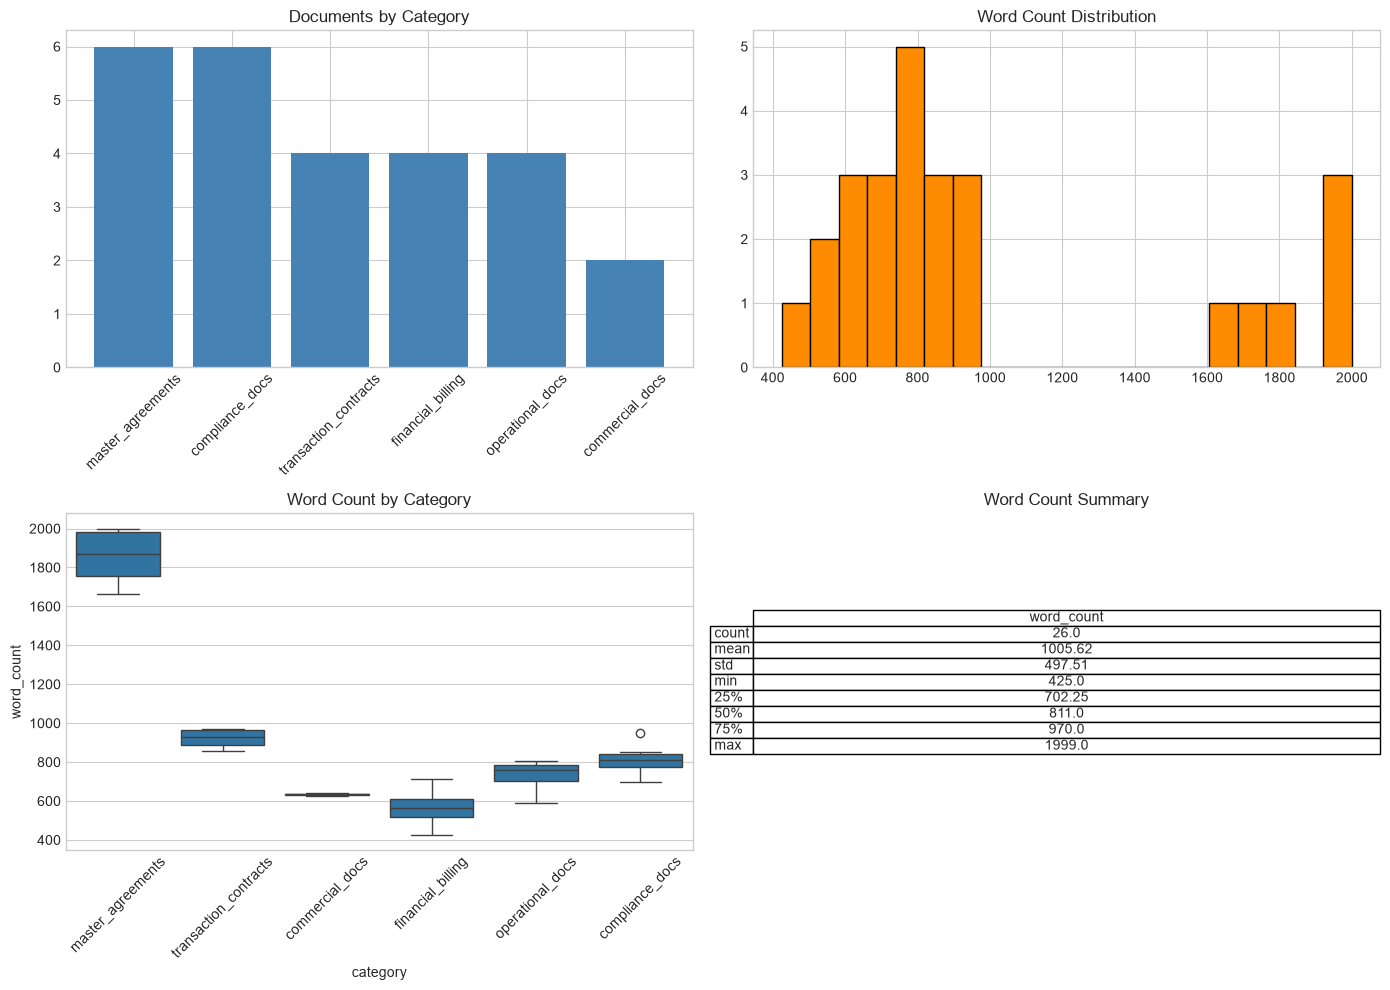


EDA visualizations saved to contract_eda.png


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)
df = pd.DataFrame(all_docs_flat)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
category_counts = df["category"].value_counts()
axes[0, 0].bar(category_counts.index.astype(str), category_counts.values, color="steelblue")
axes[0, 0].set_title("Documents by Category")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 1].hist(df["word_count"].fillna(0), bins=20, color="darkorange", edgecolor="black")
axes[0, 1].set_title("Word Count Distribution")
if not df.empty:
    sns.boxplot(data=df, x="category", y="word_count", ax=axes[1, 0])
    axes[1, 0].set_title("Word Count by Category")
    axes[1, 0].tick_params(axis="x", rotation=45)
else:
    axes[1, 0].text(0.5, 0.5, "No data", ha="center", va="center")
    axes[1, 0].set_axis_off()
summary = df[["word_count"]].describe().round(2)
axes[1, 1].axis("off")
axes[1, 1].table(cellText=summary.values, rowLabels=summary.index, colLabels=summary.columns, cellLoc="center", loc="center")
axes[1, 1].set_title("Word Count Summary")
plt.tight_layout()
plt.savefig("contract_eda.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nEDA visualizations saved to contract_eda.png")


## 2.4 Contract Entity Extraction

**TODO:** Implement entity extraction using regex patterns.

### Hints:
- Use `re.findall()` for pattern matching
- Common entities: parties, dates, monetary values, percentages
- Risk indicators: liability terms, termination clauses

In [14]:
# ============================================================================
# WEEK 2.4: CONTRACT ENTITY EXTRACTOR
# ============================================================================

class ContractEntityExtractor:
    """Extract contract entities and risk indicators."""
    def __init__(self):
        self.patterns = {
            "parties": r"(?:between|by and between)\s+([A-Z][A-Za-z\s]+(?:Inc\.|LLC|Ltd\.|Corp\.)?)",
            "effective_date": r"(?:effective\s+(?:as\s+of\s+)?(?:date)?:?\s*)(\d{1,2}[/-]\d{1,2}[/-]\d{2,4}|[A-Z][a-z]+\s+\d{1,2},?\s+\d{4})",
            "monetary_values": r"\$([\d,]+(?:\.\d{2})?)",
            "percentages": r"(\d+(?:\.\d+)?\s*%)",
            "durations": r"(\d+)\s*(?:years?|months?|days?)",
            "notice_periods": r"(?:notice\s+(?:period)?\s*(?:of)?\s*)(\d+)\s*(?:days?)",
        }
        self.risk_indicators = {"high_risk": ["unlimited liability", "indemnify", "consequential damages", "punitive damages", "sole discretion", "automatic renewal"], "medium_risk": ["liability cap", "limitation of liability", "force majeure", "material breach", "termination for convenience"], "low_risk": ["mutual indemnification", "standard terms", "annual review"]}

    def extract_entities(self, text: str) -> Dict[str, List[str]]:
        entities = {}
        for name, pattern in self.patterns.items():
            values = [match.strip() if isinstance(match, str) else str(match).strip() for match in re.findall(pattern, text or "", flags=re.IGNORECASE)]
            if values:
                entities[name] = [value for value in values if value]
        return entities

    def assess_risk_indicators(self, text: str) -> Dict[str, List[str]]:
        lowered = (text or "").lower()
        return {level: [indicator for indicator in indicators if indicator.lower() in lowered] for level, indicators in self.risk_indicators.items()}

entity_extractor = ContractEntityExtractor()
print("ContractEntityExtractor class defined")
print("Entity extraction and risk assessment implemented")


ContractEntityExtractor class defined
Entity extraction and risk assessment implemented


In [15]:
# ============================================================================
# TEST ENTITY EXTRACTION
# ============================================================================

# Test on sample document
if all_docs_flat:
    test_doc = all_docs_flat[0]
    print(f"Testing entity extraction on: {test_doc['filename']}")
    print("=" * 60)

    # Extract entities
    entities = entity_extractor.extract_entities(test_doc['full_text'])
    print("\nExtracted Entities:")
    for entity_type, values in entities.items():
        if values:
            print(f"  {entity_type}: {values[:3]}...")  # Show first 3

    # Assess risk
    risks = entity_extractor.assess_risk_indicators(test_doc['full_text'])
    print("\nRisk Indicators Found:")
    for level, indicators in risks.items():
        if indicators:
            print(f"  {level}: {indicators}")

Testing entity extraction on: MSA Sample 1.docx

Extracted Entities:
  parties: ['PrimeVolta Hardware Solutions', 'the Parties specifying the exact scope', 'the Parties']...
  percentages: ['1%']...

Risk Indicators Found:
  high_risk: ['indemnify', 'punitive damages']
  medium_risk: ['limitation of liability']


## Checkpoint: Week 2 Verification

In [16]:
# ============================================================================
# WEEK 2 CHECKPOINT - VALIDATION
# ============================================================================

print("WEEK 2 CHECKPOINT - Verification")
print("=" * 60)

checks = []

# Check 1: Document processor exists
checks.append(("DocumentProcessor initialized", doc_processor is not None))

# Check 2: load_docx method works
try:
    # Test with sample text (doesn't need real file)
    test_result = doc_processor.load_docx is not None
    checks.append(("load_docx() method exists", test_result))
except:
    checks.append(("load_docx() method exists", False))

# Check 3: Documents processed
checks.append(("Documents processed", len(all_docs_flat) > 0))

# Check 4: Entity extractor works
try:
    test_entities = entity_extractor.extract_entities("Contract value is $100,000")
    has_monetary = 'monetary_values' in test_entities
    checks.append(("Entity extraction works", has_monetary))
except Exception as e:
    checks.append(("Entity extraction works", False))
    print(f"  Error: {e}")

# Check 5: Risk assessment works
try:
    test_risks = entity_extractor.assess_risk_indicators("unlimited liability clause")
    has_high = len(test_risks.get('high_risk', [])) > 0
    checks.append(("Risk assessment works", has_high))
except Exception as e:
    checks.append(("Risk assessment works", False))
    print(f"  Error: {e}")

# Display results
all_passed = True
for check_name, check_result in checks:
    status = "PASS" if check_result else "FAIL"
    print(f"  [{status}] {check_name}")
    if not check_result:
        all_passed = False

print("\n" + "=" * 60)
if all_passed:
    print("ALL WEEK 2 CHECKPOINTS PASSED! Ready for Week 3.")
else:
    print("Some checkpoints FAILED. Review your implementation above.")

WEEK 2 CHECKPOINT - Verification
  [PASS] DocumentProcessor initialized
  [PASS] load_docx() method exists
  [PASS] Documents processed
  [PASS] Entity extraction works
  [PASS] Risk assessment works

ALL WEEK 2 CHECKPOINTS PASSED! Ready for Week 3.


---

# WEEK 3: Vector Store & Embeddings

**Difficulty: Medium** - Implement semantic search functionality.

---

## Learning Objectives

By the end of Week 3, you will:
- [ ] Initialize ChromaDB for vector storage
- [ ] Implement document indexing with embeddings
- [ ] Create semantic search functions
- [ ] Understand similarity scoring

---

## 3.1 ChromaDB Vector Store Class

**TODO:** Implement the vector store with search capabilities.

### Hints:
- Use `chromadb.PersistentClient` for storage
- Create collections with `client.get_or_create_collection()`
- Use your `traced_embedding()` function for embeddings
- ChromaDB's `query()` method returns results with distances

In [17]:
# ============================================================================
# WEEK 3.1: CHROMADB VECTOR STORE
# ============================================================================

import chromadb

class ContractVectorStore:
    """ChromaDB-based vector store with Langfuse observability."""
    def __init__(self, persist_directory: str = "./chroma_contracts_db"):
        self.client = chromadb.PersistentClient(path=persist_directory)
        self.embedding_model = "text-embedding-3-small"
        self.collections = {}
        langfuse.trace(name="vectorstore-init", session_id=SESSION_ID, input={"persist_directory": persist_directory})
        print(f"ChromaDB initialized at: {persist_directory}")

    def create_collection(self, name: str):
        collection = self.client.get_or_create_collection(name=name, metadata={"hnsw:space": "cosine"})
        self.collections[name] = collection
        return collection

    def add_documents(self, collection_name: str, documents: List[Dict]):
        trace = langfuse.trace(name=f"index-{collection_name}", session_id=SESSION_ID, input={"doc_count": len(documents)})
        collection = self.create_collection(collection_name)
        ids, embeddings, docs, metadatas = [], [], [], []
        for index, document in enumerate(documents):
            doc_id = str(document.get("doc_id") or f"document-{index}")
            text = str(document.get("full_text", ""))[:8000]
            ids.append(doc_id)
            docs.append(text)
            embeddings.append(traced_embedding(text, f"embed-{doc_id}"))
            metadatas.append({"filename": str(document.get("filename", "")), "category": str(document.get("category", "")), "word_count": int(document.get("word_count", 0) or 0), "doc_id": doc_id})
        if ids:
            collection.upsert(ids=ids, embeddings=embeddings, documents=docs, metadatas=metadatas)
        trace.update(output={"indexed": len(ids)})
        print(f"Indexed {len(ids)} documents into '{collection_name}'")

    def search(self, collection_name: str, query: str, n_results: int = 5) -> List[Dict]:
        trace = langfuse.trace(name="semantic-search", session_id=SESSION_ID, input={"query": query, "collection": collection_name})
        collection = self.collections.get(collection_name) or self.client.get_collection(collection_name)
        self.collections[collection_name] = collection
        result_count = min(max(1, n_results), collection.count())
        if result_count == 0:
            trace.update(output={"results_count": 0})
            return []
        results = collection.query(query_embeddings=[traced_embedding(query, "search-query")], n_results=result_count, include=["documents", "metadatas", "distances"])
        formatted = []
        for document, metadata, distance in zip((results.get("documents") or [[]])[0], (results.get("metadatas") or [[]])[0], (results.get("distances") or [[]])[0]):
            formatted.append({"document": document, "metadata": metadata or {}, "similarity": max(0.0, min(1.0, 1.0 - float(distance)))})
        trace.update(output={"results_count": len(formatted)})
        return formatted

print("ContractVectorStore class defined")
print("ChromaDB collection, indexing, and semantic search implemented")


ContractVectorStore class defined
ChromaDB collection, indexing, and semantic search implemented


### Expected Output for search():
```python
[
    {
        'document': 'Provider shall perform the Services...',
        'metadata': {'filename': 'sample_msa.docx', 'category': 'master_agreements'},
        'similarity': 0.87
    },
    ...
]
```

In [18]:
# ============================================================================
# WEEK 3.2: INITIALIZE AND INDEX DOCUMENTS
# ============================================================================

vector_store = ContractVectorStore()
print("\n" + "=" * 60)
print("INDEXING CONTRACT DOCUMENTS")
print("=" * 60)
if all_docs_flat:
    vector_store.add_documents("contracts_all", all_docs_flat)
else:
    print("No documents to index!")
langfuse.flush()
print("\nIndexing complete!")


ChromaDB initialized at: ./chroma_contracts_db

INDEXING CONTRACT DOCUMENTS
Indexed 26 documents into 'contracts_all'

Indexing complete!


In [19]:
# ============================================================================
# WEEK 3.2A: SEARCH ONE OR MULTIPLE DOCUMENTS
# ============================================================================

from pprint import pprint
search_query = "liability limitations and caps"

print("SEARCH RESULT FOR ONE DOCUMENT")
print("=" * 60)
pprint(vector_store.search("contracts_all", search_query, n_results=1), sort_dicts=False, width=120)

print("\nSEARCH RESULTS FOR MULTIPLE DOCUMENTS")
print("=" * 60)
pprint(vector_store.search("contracts_all", search_query, n_results=3), sort_dicts=False, width=120)


SEARCH RESULT FOR ONE DOCUMENT
[{'document': 'NON-DISCLOSURE AGREEMENT (NDA SAMPLE 2)\n'
              'Mutual Proprietary Information, Intellectual Property & Data Protection Agreement\n'
              'Between PrimeVolta Hardware Solutions & FinSecure Services\n'
              '1. INTRODUCTION AND CONTEXT OF DISCLOSURE\n'
              'This Non-Disclosure Agreement (“Agreement”) is executed between PrimeVolta Hardware Solutions (“Party '
              'A”) and FinSecure Services (“Party B”) for the purpose of establishing a secure, confidential, and '
              'legally enforceable framework governing the mutual exchange of sensitive information required for '
              'hardware development, technical evaluation, financial planning, integration scoping, operational '
              'workflow mapping, and other BFSI-related business collaborations. The Parties recognize that '
              'discussions between a hardware engineering manufacturer and a BFSI-grade financial se

## 3.3 Semantic Search Examples

The next search cell displays one result and multiple results using the same structure as the expected output.


In [20]:
# ============================================================================
# WEEK 3.3: SEMANTIC SEARCH EXAMPLES
# ============================================================================

print("SEMANTIC SEARCH EXAMPLES")
print("=" * 60)

# Test queries
test_queries = [
    "liability limitations and caps",
    "payment terms and invoicing",
    "termination for convenience",
    "intellectual property rights",
    "confidentiality obligations"
]

for query in test_queries:
    print(f"\nQuery: '{query}'")
    print("-" * 40)

    results = vector_store.search("contracts_all", query, n_results=3)

    for i, result in enumerate(results, 1):
        print(f"  {i}. [{result.get('similarity', 0):.3f}] {result.get('metadata', {}).get('filename', 'unknown')}")
        # Show snippet
        doc_text = result.get('document', '')[:150]
        print(f"     '{doc_text}...'")

langfuse.flush()

SEMANTIC SEARCH EXAMPLES

Query: 'liability limitations and caps'
----------------------------------------
  1. [0.277] NDA sample 2.docx
     'NON-DISCLOSURE AGREEMENT (NDA SAMPLE 2)
Mutual Proprietary Information, Intellectual Property & Data Protection Agreement
Between PrimeVolta Hardware ...'
  2. [0.267] Industry specific complinace sample 1.docx
     'Sample 1: Industry-Specific Compliance Annexure – Annexure A
1. Purpose and Scope
This Annexure (“Annexure A”) forms an integral part of the Master Se...'
  3. [0.262] RATE CARD AGREEMENT Sample 2.docx
     'RATE CARD AGREEMENT – SAMPLE 2
Between PrimeVolta Hardware Solutions & FinSecure Services
1. PURPOSE, INTENT, AND STRATEGIC OBJECTIVE OF THIS AGREEMEN...'

Query: 'payment terms and invoicing'
----------------------------------------
  1. [0.569] Billing schedule sample 2.docx
     'Primevolta Hardware Solutions
Detailed Billing Schedule Agreement
Client: FinSecure Services
Date: 11th December 2025
1. Purpose
This Billing Sched

## 3.4 Search with Metadata Filters (BONUS)

**BONUS TODO:** Implement filtered search.

### Hints:
- ChromaDB supports `where` parameter for filtering
- Filter format: `{"category": "master_agreements"}`

In [21]:
# ============================================================================
# WEEK 3.4: FILTERED SEARCH (BONUS)
# ============================================================================

def search_with_filter(self, collection_name: str, query: str, filter_dict: Dict = None, n_results: int = 5) -> List[Dict]:
    collection = self.collections.get(collection_name) or self.client.get_collection(collection_name)
    self.collections[collection_name] = collection
    result_count = min(max(1, n_results), collection.count())
    if result_count == 0:
        return []
    query_args = {"query_embeddings": [traced_embedding(query, "filtered-search-query")], "n_results": result_count, "include": ["documents", "metadatas", "distances"]}
    if filter_dict:
        query_args["where"] = filter_dict
    results = collection.query(**query_args)
    return [{"document": document, "metadata": metadata or {}, "similarity": max(0.0, min(1.0, 1.0 - float(distance)))} for document, metadata, distance in zip((results.get("documents") or [[]])[0], (results.get("metadatas") or [[]])[0], (results.get("distances") or [[]])[0])]

ContractVectorStore.search_with_filter = search_with_filter
print("search_with_filter() method added (BONUS)")


search_with_filter() method added (BONUS)


## Checkpoint: Week 3 Verification

In [22]:
# ============================================================================
# WEEK 3 CHECKPOINT - VALIDATION
# ============================================================================

print("WEEK 3 CHECKPOINT - Verification")
print("=" * 60)

checks = []

# Check 1: Vector store initialized
checks.append(("VectorStore initialized", vector_store is not None))

# Check 2: ChromaDB client created
try:
    checks.append(("ChromaDB client created", vector_store.client is not None))
except:
    checks.append(("ChromaDB client created", False))

# Check 3: Collection created
try:
    has_collection = "contracts_all" in vector_store.collections
    checks.append(("Collection created", has_collection))
except:
    checks.append(("Collection created", False))

# Check 4: Search returns results
try:
    results = vector_store.search("contracts_all", "liability", n_results=1)
    checks.append(("Search returns results", len(results) > 0))
except Exception as e:
    checks.append(("Search returns results", False))
    print(f"  Error: {e}")

# Check 5: Results have correct structure
try:
    if results:
        has_doc = 'document' in results[0]
        has_meta = 'metadata' in results[0]
        has_sim = 'similarity' in results[0]
        checks.append(("Result structure correct", has_doc and has_meta and has_sim))
    else:
        checks.append(("Result structure correct", False))
except:
    checks.append(("Result structure correct", False))

# Display results
all_passed = True
for check_name, check_result in checks:
    status = "PASS" if check_result else "FAIL"
    print(f"  [{status}] {check_name}")
    if not check_result:
        all_passed = False

print("\n" + "=" * 60)
if all_passed:
    print("ALL WEEK 3 CHECKPOINTS PASSED! Ready for Week 4.")
else:
    print("Some checkpoints FAILED. Review your implementation above.")

WEEK 3 CHECKPOINT - Verification
  [PASS] VectorStore initialized
  [PASS] ChromaDB client created
  [PASS] Collection created
  [PASS] Search returns results
  [PASS] Result structure correct

ALL WEEK 3 CHECKPOINTS PASSED! Ready for Week 4.


---

# WEEK 4: Single Agent Design

**Difficulty: Medium-Hard** - Build specialized risk assessment agents.

---

## Learning Objectives

By the end of Week 4, you will:
- [ ] Define Pydantic models for structured outputs
- [ ] Create LangChain prompt templates
- [ ] Implement specialized risk agents
- [ ] Integrate Langfuse callback handlers

---

## Key Concept: Agent Architecture

Each agent follows this pattern:
```
Prompt Template -> LLM -> Output Parser -> Structured Result
       |              |           |
       v              v           v
   (Expert persona)  (GPT-4)   (Pydantic model)
```

All calls are traced through Langfuse for observability.

## 4.1 Pydantic Models for Structured Output

**TODO:** Complete the Pydantic models for each risk type.

### Hints:
- Use `Field()` with descriptions to guide the LLM
- Include `confidence` field (0.0-1.0) in all models
- Think about what fields each risk type needs

In [23]:
# ============================================================================
# WEEK 4.1: PYDANTIC MODELS
# ============================================================================

from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import PydanticOutputParser
from langfuse.callback import CallbackHandler as LangfuseCallbackHandler

class LegalRiskAssessment(BaseModel):
    """Structured output for legal risk analysis."""
    contract_type: str = Field(description="Type of contract such as MSA, NDA, or SOW")
    risk_level: str = Field(description="Overall risk level: LOW, MEDIUM, HIGH, or CRITICAL")
    liability_exposure: str = Field(description="Summary of liability exposure and limitations")
    ip_risks: List[str] = Field(default_factory=list, description="Intellectual property risks")
    indemnification_issues: List[str] = Field(default_factory=list, description="Indemnification concerns")
    compliance_gaps: List[str] = Field(default_factory=list, description="Legal or regulatory compliance gaps")
    recommended_changes: List[str] = Field(default_factory=list, description="Recommended contract changes")
    confidence: float = Field(ge=0.0, le=1.0, description="Assessment confidence from 0 to 1")

print("LegalRiskAssessment model defined")
print(f"Fields: {list(LegalRiskAssessment.model_fields.keys())}")


LegalRiskAssessment model defined
Fields: ['contract_type', 'risk_level', 'liability_exposure', 'ip_risks', 'indemnification_issues', 'compliance_gaps', 'recommended_changes', 'confidence']


In [24]:
# ============================================================================
# FINANCIAL RISK ASSESSMENT MODEL
# ============================================================================

class FinancialRiskAssessment(BaseModel):
    """Structured output for financial risk analysis."""
    total_contract_value: str = Field(description="Total estimated contract value")
    payment_terms: str = Field(description="Summary of payment terms")
    pricing_risks: List[str] = Field(default_factory=list, description="Pricing and cost escalation risks")
    penalty_clauses: List[str] = Field(default_factory=list, description="Financial penalties and credits")
    cash_flow_impact: str = Field(description="Expected cash flow impact")
    financial_exposure: str = Field(description="Summary of financial exposure")
    risk_level: str = Field(description="Overall risk level: LOW, MEDIUM, HIGH, or CRITICAL")
    confidence: float = Field(ge=0.0, le=1.0, description="Assessment confidence from 0 to 1")

print("FinancialRiskAssessment model defined")
print(f"Fields: {list(FinancialRiskAssessment.model_fields.keys())}")


FinancialRiskAssessment model defined
Fields: ['total_contract_value', 'payment_terms', 'pricing_risks', 'penalty_clauses', 'cash_flow_impact', 'financial_exposure', 'risk_level', 'confidence']


In [25]:
# ============================================================================
# OPERATIONAL RISK ASSESSMENT MODEL
# ============================================================================

class OperationalRiskAssessment(BaseModel):
    """Structured output for operational risk analysis."""
    service_scope: str = Field(description="Summary of service scope")
    sla_requirements: List[str] = Field(default_factory=list, description="Service level requirements")
    delivery_risks: List[str] = Field(default_factory=list, description="Delivery and timeline risks")
    resource_requirements: str = Field(description="Required people, skills, and infrastructure")
    dependency_risks: List[str] = Field(default_factory=list, description="External or internal dependencies")
    mitigation_strategies: List[str] = Field(default_factory=list, description="Operational mitigation strategies")
    risk_level: str = Field(description="Overall risk level: LOW, MEDIUM, HIGH, or CRITICAL")
    confidence: float = Field(ge=0.0, le=1.0, description="Assessment confidence from 0 to 1")

print("OperationalRiskAssessment model defined")
print(f"Fields: {list(OperationalRiskAssessment.model_fields.keys())}")


OperationalRiskAssessment model defined
Fields: ['service_scope', 'sla_requirements', 'delivery_risks', 'resource_requirements', 'dependency_risks', 'mitigation_strategies', 'risk_level', 'confidence']


## 4.2 Langfuse Callback Handler Factory

**PROVIDED** - This helper creates traced handlers for LangChain.

In [26]:
# ============================================================================
# WEEK 4.2: LANGFUSE CALLBACK HANDLER (PROVIDED)
# ============================================================================

def get_langfuse_handler(trace_name: str, tags: List[str] = None) -> LangfuseCallbackHandler:
    """
    Create a Langfuse callback handler for LangChain.

    This traces:
    - Prompt formatting
    - LLM calls (input/output/tokens)
    - Output parsing
    - Errors
    """
    return LangfuseCallbackHandler(
        secret_key=os.environ.get('LANGFUSE_SECRET_KEY'),
        public_key=os.environ.get('LANGFUSE_PUBLIC_KEY'),
        host=os.environ.get('LANGFUSE_HOST'),
        session_id=SESSION_ID,
        trace_name=trace_name,
        tags=tags or []
    )

print("get_langfuse_handler() factory defined")

get_langfuse_handler() factory defined


## 4.3 Legal Risk Agent

**TODO:** Implement the Legal Risk Agent from scratch.

### Hints:
- Create a `ChatPromptTemplate` with system and human messages
- Use `PydanticOutputParser` with your model
- Chain: prompt | llm | parser
- Include `{format_instructions}` in the prompt

In [27]:
# ============================================================================
# WEEK 4.3: LEGAL RISK AGENT
# ============================================================================

class LegalRiskAgent:
    """Legal risk assessment agent returning a typed Pydantic result."""

    def __init__(self, model: str = "gpt-4o-mini"):
        self.model = model
        self.parser = PydanticOutputParser(pydantic_object=LegalRiskAssessment)
        self.prompt = ChatPromptTemplate.from_messages([
            (
                "system",
                "You are a senior commercial contract attorney. Analyze contracts carefully, "
                "identify concrete legal risks, and never invent facts. Return only the requested "
                "structured assessment.\n\n{format_instructions}"
            ),
            (
                "human",
                "Analyze this contract for legal risk, liability, intellectual property, "
                "indemnification, and compliance issues.\n\nContract:\n{contract_text}"
            ),
        ])

    def analyze(self, contract_text: str, doc_id: str = "unknown") -> LegalRiskAssessment:
        """Analyze contract text for legal risks."""
        handler = get_langfuse_handler(f"legal-risk-{doc_id}", tags=["week4", "legal"])
        llm = ChatOpenAI(model=self.model, temperature=0, callbacks=[handler])
        chain = self.prompt | llm | self.parser
        return chain.invoke({
            "contract_text": contract_text,
            "format_instructions": self.parser.get_format_instructions(),
        })

print("LegalRiskAgent class defined")
print("Legal agent prompt, parser, and LCEL chain implemented")


LegalRiskAgent class defined
Legal agent prompt, parser, and LCEL chain implemented


In [28]:
# ============================================================================
# WEEK 4.4: FINANCIAL RISK AGENT
# ============================================================================

class FinancialRiskAgent:
    """Financial risk assessment agent returning a typed Pydantic result."""

    def __init__(self, model: str = "gpt-4o-mini"):
        self.model = model
        self.parser = PydanticOutputParser(pydantic_object=FinancialRiskAssessment)
        self.prompt = ChatPromptTemplate.from_messages([
            (
                "system",
                "You are a senior commercial finance and procurement analyst. Assess pricing, "
                "payment, cash-flow, penalty, and cost-escalation risks using only the contract text.\n\n"
                "{format_instructions}"
            ),
            (
                "human",
                "Analyze this contract for financial risk and exposure.\n\nContract:\n{contract_text}"
            ),
        ])

    def analyze(self, contract_text: str, doc_id: str = "unknown") -> FinancialRiskAssessment:
        """Analyze contract text for financial risks."""
        handler = get_langfuse_handler(f"financial-risk-{doc_id}", tags=["week4", "financial"])
        llm = ChatOpenAI(model=self.model, temperature=0, callbacks=[handler])
        chain = self.prompt | llm | self.parser
        return chain.invoke({
            "contract_text": contract_text,
            "format_instructions": self.parser.get_format_instructions(),
        })

print("FinancialRiskAgent class defined")
print("Financial agent prompt, parser, and LCEL chain implemented")


FinancialRiskAgent class defined
Financial agent prompt, parser, and LCEL chain implemented


In [29]:
# ============================================================================
# WEEK 4.5: OPERATIONAL RISK AGENT
# ============================================================================

class OperationalRiskAgent:
    """Operational risk assessment agent returning a typed Pydantic result."""

    def __init__(self, model: str = "gpt-4o-mini"):
        self.model = model
        self.parser = PydanticOutputParser(pydantic_object=OperationalRiskAssessment)
        self.prompt = ChatPromptTemplate.from_messages([
            (
                "system",
                "You are a senior service delivery and operations leader. Assess service scope, "
                "SLAs, delivery timelines, resources, dependencies, and practical mitigations.\n\n"
                "{format_instructions}"
            ),
            (
                "human",
                "Analyze this contract for operational risk.\n\nContract:\n{contract_text}"
            ),
        ])

    def analyze(self, contract_text: str, doc_id: str = "unknown") -> OperationalRiskAssessment:
        """Analyze contract text for operational risks."""
        handler = get_langfuse_handler(f"operational-risk-{doc_id}", tags=["week4", "operational"])
        llm = ChatOpenAI(model=self.model, temperature=0, callbacks=[handler])
        chain = self.prompt | llm | self.parser
        return chain.invoke({
            "contract_text": contract_text,
            "format_instructions": self.parser.get_format_instructions(),
        })

print("OperationalRiskAgent class defined")
print("Operational agent prompt, parser, and LCEL chain implemented")


OperationalRiskAgent class defined
Operational agent prompt, parser, and LCEL chain implemented


In [30]:
# ============================================================================
# INITIALIZE ALL AGENTS
# ============================================================================

# Create agent instances
legal_agent = LegalRiskAgent()
financial_agent = FinancialRiskAgent()
operational_agent = OperationalRiskAgent()

print("Risk Assessment Agents Initialized:")
print("  - LegalRiskAgent")
print("  - FinancialRiskAgent")
print("  - OperationalRiskAgent")

Risk Assessment Agents Initialized:
  - LegalRiskAgent
  - FinancialRiskAgent
  - OperationalRiskAgent


## 4.6 Test Your Agents

Run each agent and verify the structured outputs.

In [31]:
# ============================================================================
# WEEK 4.6: TEST AGENTS
# ============================================================================

print("TESTING RISK ASSESSMENT AGENTS")
print("=" * 60)

# Get test contract text
if all_docs_flat:
    test_text = all_docs_flat[0]['full_text']
    test_id = all_docs_flat[0]['doc_id']
else:
    test_text = "Sample contract with liability and payment terms."
    test_id = "TEST-001"

print(f"Testing on document: {test_id}")
print(f"Text length: {len(test_text)} characters")

# Test Legal Agent
print("\n" + "-" * 40)
print("LEGAL RISK AGENT")
print("-" * 40)
try:
    legal_result = legal_agent.analyze(test_text[:8000], test_id)
    print(f"Risk Level: {legal_result.risk_level}")
    print(f"Contract Type: {legal_result.contract_type}")
    print(f"Confidence: {legal_result.confidence}")
except Exception as e:
    print(f"Error: {e}")
    legal_result = None

# Test Financial Agent
print("\n" + "-" * 40)
print("FINANCIAL RISK AGENT")
print("-" * 40)
try:
    financial_result = financial_agent.analyze(test_text[:8000], test_id)
    print(f"Risk Level: {financial_result.risk_level}")
    print(f"Contract Value: {financial_result.total_contract_value}")
    print(f"Confidence: {financial_result.confidence}")
except Exception as e:
    print(f"Error: {e}")
    financial_result = None

# Test Operational Agent
print("\n" + "-" * 40)
print("OPERATIONAL RISK AGENT")
print("-" * 40)
try:
    operational_result = operational_agent.analyze(test_text[:8000], test_id)
    print(f"Risk Level: {operational_result.risk_level}")
    print(f"Service Scope: {operational_result.service_scope[:100]}...")
    print(f"Confidence: {operational_result.confidence}")
except Exception as e:
    print(f"Error: {e}")
    operational_result = None

langfuse.flush()
print("\nAll agent traces sent to Langfuse!")

TESTING RISK ASSESSMENT AGENTS
Testing on document: 05403fbd35b4
Text length: 14707 characters

----------------------------------------
LEGAL RISK AGENT
----------------------------------------
Risk Level: MEDIUM
Contract Type: MASTER SERVICES AGREEMENT
Confidence: 0.85

----------------------------------------
FINANCIAL RISK AGENT
----------------------------------------
Risk Level: MEDIUM
Contract Value: Not specified in the contract
Confidence: 0.8

----------------------------------------
OPERATIONAL RISK AGENT
----------------------------------------
Risk Level: HIGH
Service Scope: The Vendor will provide comprehensive supply, delivery, installation, commissioning, maintenance, an...
Confidence: 0.85

All agent traces sent to Langfuse!


## Checkpoint: Week 4 Verification

In [32]:
# ============================================================================
# WEEK 4 CHECKPOINT - VALIDATION
# ============================================================================

print("WEEK 4 CHECKPOINT - Verification")
print("=" * 60)

checks = []

# Check 1: Pydantic models defined
try:
    legal_fields = list(LegalRiskAssessment.model_fields.keys())
    has_required = 'risk_level' in legal_fields and 'confidence' in legal_fields
    checks.append(("Pydantic models complete", has_required and len(legal_fields) >= 5))
except:
    checks.append(("Pydantic models complete", False))

# Check 2: Agents initialized
checks.append(("Legal agent initialized", legal_agent is not None))
checks.append(("Financial agent initialized", financial_agent is not None))
checks.append(("Operational agent initialized", operational_agent is not None))

# Check 3: Legal agent works
try:
    checks.append(("Legal agent produces output", legal_result is not None))
except:
    checks.append(("Legal agent produces output", False))

# Check 4: Financial agent works
try:
    checks.append(("Financial agent produces output", financial_result is not None))
except:
    checks.append(("Financial agent produces output", False))

# Check 5: Operational agent works
try:
    checks.append(("Operational agent produces output", operational_result is not None))
except:
    checks.append(("Operational agent produces output", False))

# Display results
all_passed = True
for check_name, check_result in checks:
    status = "PASS" if check_result else "FAIL"
    print(f"  [{status}] {check_name}")
    if not check_result:
        all_passed = False

print("\n" + "=" * 60)
if all_passed:
    print("ALL WEEK 4 CHECKPOINTS PASSED! Ready for Week 5.")
else:
    print("Some checkpoints FAILED. Review your implementation above.")

WEEK 4 CHECKPOINT - Verification
  [PASS] Pydantic models complete
  [PASS] Legal agent initialized
  [PASS] Financial agent initialized
  [PASS] Operational agent initialized
  [PASS] Legal agent produces output
  [PASS] Financial agent produces output
  [PASS] Operational agent produces output

ALL WEEK 4 CHECKPOINTS PASSED! Ready for Week 5.
